In [1]:
import os
from pathlib import Path
from src.components.Solar import PVLibWeatherFetcher
from datetime import datetime
import pandas as pd
import numpy as np
import pvlib
from pvlib import solarposition

In [39]:
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'weather.csv'
Weather = PVLibWeatherFetcher('user')
start = 20181231
end = 20200101
df, meta, Location = Weather.fetch('Кызыл-Хая', start, end)
df.to_csv(data_path)
print(df)

                              dni    dhi     ghi  temp_air  wind_speed
2018-12-31 00:00:00+00:00    0.00   0.00    0.00    -24.63        3.69
2018-12-31 01:00:00+00:00    0.00   0.00    0.00    -24.25        3.48
2018-12-31 02:00:00+00:00   24.93  16.15   13.62    -24.05        3.29
2018-12-31 03:00:00+00:00   85.86  57.55   75.10    -22.80        3.11
2018-12-31 04:00:00+00:00  168.11  97.49  142.00    -20.22        2.84
...                           ...    ...     ...       ...         ...
2020-01-01 19:00:00+00:00    0.00   0.00    0.00    -22.37        4.04
2020-01-01 20:00:00+00:00    0.00   0.00    0.00    -22.24        4.02
2020-01-01 21:00:00+00:00    0.00   0.00    0.00    -22.13        4.00
2020-01-01 22:00:00+00:00    0.00   0.00    0.00    -22.04        3.99
2020-01-01 23:00:00+00:00    0.00   0.00    0.00    -21.99        3.97

[8808 rows x 5 columns]


In [41]:
Location

Location: 
  name: None
  latitude: 50.0483456
  longitude: 89.8706419
  altitude: 2126.0
  tz: Asia/Krasnoyarsk

In [2]:
latitude, longitude = 50.0483456, 89.8706419
altitude = 2126.0
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'weather.csv'
df = pd.read_csv(data_path, index_col = 0)
df

,dni,dhi,ghi,temp_air,wind_speed
2018-12-31 00:00:00+00:00,0.00,0.00,0.00,-24.63,3.69
2018-12-31 01:00:00+00:00,0.00,0.00,0.00,-24.25,3.48
2018-12-31 02:00:00+00:00,24.93,16.15,13.62,-24.05,3.29
2018-12-31 03:00:00+00:00,85.86,57.55,75.10,-22.80,3.11
2018-12-31 04:00:00+00:00,168.11,97.49,142.00,-20.22,2.84
...,...,...,...,...,...
2020-01-01 19:00:00+00:00,0.00,0.00,0.00,-22.37,4.04
2020-01-01 20:00:00+00:00,0.00,0.00,0.00,-22.24,4.02
2020-01-01 21:00:00+00:00,0.00,0.00,0.00,-22.13,4.00
2020-01-01 22:00:00+00:00,0.00,0.00,0.00,-22.04,3.99


In [3]:
df.describe()

,dni,dhi,ghi,temp_air,wind_speed
count,8808.000000,8808.000000,8808.000000,8808.000000,8808.000000
mean,167.514250,69.472842,148.784079,-3.809993,3.514649
std,255.195177,99.772298,216.302589,13.025713,2.236110
min,0.000000,0.000000,0.000000,-36.390000,0.010000
25%,0.000000,0.000000,0.000000,-15.002500,2.110000
50%,0.465000,9.385000,8.200000,-2.455000,2.870000
75%,272.162500,113.582500,248.082500,6.572500,4.260000
max,1071.880000,582.060000,949.350000,23.540000,19.350000


In [4]:
from timezonefinder import TimezoneFinder
from pvlib.location import Location
tf = TimezoneFinder()
timezone = tf.timezone_at(lng=longitude, lat=latitude)
Location = Location(latitude=latitude, longitude=longitude,
                    altitude = altitude, tz=timezone)

In [5]:
Location

Location: 
  name: None
  latitude: 50.0483456
  longitude: 89.8706419
  altitude: 2126.0
  tz: Asia/Krasnoyarsk

In [6]:
start = 20181231
end = 20200101
START = datetime.strptime(str(start), "%Y%m%d").date().isoformat()
END = datetime.strptime(str(end), "%Y%m%d").date().isoformat()
times = pd.date_range(start=START, end=END, freq='h', tz=Location.tz)
solpos = solarposition.get_solarposition(times, Location.latitude, Location
                                         .longitude, Location.altitude)

In [7]:
df.index = pd.to_datetime(df.index)
df.index = df.index.tz_convert(tz=Location.tz)
df = df.reindex(times)

In [8]:
HVL_320 = {
    'Name': 'HVL-320',
    'Technology' : 'CIGS',
    'Bifacial' : None,
    'STC': 320,
    'PTC': 300,
    'A_c': 1.67,
    'Length': 1.671,
    'Width': 1.002,
    'N_s': 60,
    'I_sc_ref': 9.33,
    'V_oc_ref': 43.97,
    'I_mp_ref': 8.62,
    'V_mp_ref': 35.36,
    'alpha_sc' : 0.037,          # Коэффициент температурной зависимости тока короткого замыкания
    'beta_oc': -0.249,           # Коэффициент температурной зависимости напряжения холостого хода
    'T_NOCT': 38.8,              # Номинальная рабочая температура ячейки
    'a_ref': 1.8,                # Диодный коэффициент
    'I_L_ref': 9.33,             # Ток фотогенерации при эталонных условиях
    'I_o_ref': 1e-10,            # Обратный ток насыщения диода при эталонных условиях
    'R_s': 0.35,                 # Сопротивление последовательное
    'R_sh_ref': 1000,            # Сопротивление шунтирующее при эталонных условиях
    'Adjust': 1,                 # Корректирующий коэффициент
    'gamma_r': -0.39,            # Температурный коэффициент мощности
    'BIPV': False                # Интеграция в здание (Building Integrated )
}

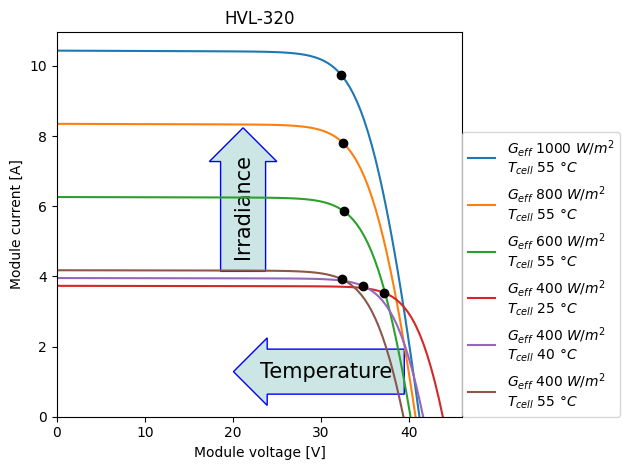

        i_sc       v_oc      i_mp       v_mp        p_mp
0  10.436347  41.153174  9.738489  32.299689  314.550169
1   8.349662  40.711185  7.805588  32.479837  253.524214
2   6.262685  40.141362  5.863466  32.543728  190.819036
3   3.731478  43.808560  3.539673  37.090707  131.288974
4   3.953447  41.577811  3.729415  34.732515  129.531959
5   4.175415  39.338241  3.913368  32.390986  126.757858


In [9]:
from pvlib import pvsystem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example module parameters for the Canadian Solar CS5P-220M:

cases = [
    (1000, 55),
    (800, 55),
    (600, 55),
    (400, 25),
    (400, 40),
    (400, 55)
]

conditions = pd.DataFrame(cases, columns=['Geff', 'Tcell'])

# adjust the reference parameters according to the operating
# conditions using the De Soto model:
IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
    conditions['Geff'],
    conditions['Tcell'],
    alpha_sc=HVL_320['alpha_sc'],
    a_ref=HVL_320['a_ref'],
    I_L_ref=HVL_320['I_L_ref'],
    I_o_ref=HVL_320['I_o_ref'],
    R_sh_ref=HVL_320['R_sh_ref'],
    R_s=HVL_320['R_s'],
    EgRef=1.121,
    dEgdT=-0.0002677
)

# plug the parameters into the SDE and solve for IV curves:
SDE_params = {
    'photocurrent': IL,
    'saturation_current': I0,
    'resistance_series': Rs,
    'resistance_shunt': Rsh,
    'nNsVth': nNsVth
}
curve_info = pvsystem.singlediode(method='lambertw', **SDE_params)
v = pd.DataFrame(np.linspace(0., curve_info['v_oc'], 100))
i = pd.DataFrame(pvsystem.i_from_v(voltage=v, method='lambertw', **SDE_params))

# plot the calculated curves:
plt.figure()
for idx, case in conditions.iterrows():
    label = (
        "$G_{eff}$ " + f"{case['Geff']} $W/m^2$\n"
        "$T_{cell}$ " + f"{case['Tcell']} $\\degree C$"
    )
    plt.plot(v[idx], i[idx], label=label)
    v_mp = curve_info['v_mp'][idx]
    i_mp = curve_info['i_mp'][idx]
    # mark the MPP
    plt.plot([v_mp], [i_mp], ls='', marker='o', c='k')

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(loc=(1.0, 0))
plt.xlabel('Module voltage [V]')
plt.ylabel('Module current [A]')
plt.title(HVL_320['Name'])
plt.gcf().set_tight_layout(True)


# draw trend arrows
def draw_arrow(ax, label, x0, y0, rotation, size, direction):
    style = direction + 'arrow'
    bbox_props = dict(boxstyle=style, fc=(0.8, 0.9, 0.9), ec="b", lw=1)
    t = ax.text(x0, y0, label, ha="left", va="bottom", rotation=rotation,
                size=size, bbox=bbox_props, zorder=-1)

    bb = t.get_bbox_patch()
    bb.set_boxstyle(style, pad=0.6)


ax = plt.gca()
draw_arrow(ax, 'Irradiance', 20, 4.5, 90, 15, 'r')
draw_arrow(ax, 'Temperature', 23, 1, 0, 15, 'l')
plt.show()

print(pd.DataFrame({
    'i_sc': curve_info['i_sc'],
    'v_oc': curve_info['v_oc'],
    'i_mp': curve_info['i_mp'],
    'v_mp': curve_info['v_mp'],
    'p_mp': curve_info['p_mp'],
}))

In [10]:
import pvlib
from pvlib import pvsystem, location, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
cec_inverters = pvlib.pvsystem.retrieve_sam('cecinverter')
cec_inverter  = cec_inverters['AEG_Power_Solutions__Protect_MPV_030_01__480V_']

In [11]:
from pvlib import pvsystem, location, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
tracker_mount = pvsystem.SingleAxisTrackerMount(
    axis_tilt=0,
    axis_azimuth=0,
    max_angle=60,
    backtrack=True,
    gcr=0.4,
)

temperature_model_parameters = TEMPERATURE_MODEL_PARAMETERS['pvsyst']['freestanding']

modules_per_string = 100
strings_per_inverter = 13

array = pvsystem.Array(
    mount=tracker_mount,
    module_parameters=HVL_320,
    modules_per_string=modules_per_string,
    strings=strings_per_inverter,
    temperature_model_parameters=temperature_model_parameters,
)
system = pvsystem.PVSystem(
    arrays=[array],
    inverter_parameters=cec_inverter,
)

mc = modelchain.ModelChain(
    system,
    Location,
    aoi_model='physical',
    spectral_model='no_loss',
)
mc.run_model(df)

C:\Users\Илья\PycharmProjects\masters-thesis\.venv1\lib\site-packages\scipy\optimize\_chandrupatla.py:438: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


ModelChain: 
  name: None
  clearsky_model: ineichen
  transposition_model: haydavies
  solar_position_method: nrel_numpy
  airmass_model: kastenyoung1989
  dc_model: cec
  ac_model: sandia_inverter
  aoi_model: physical_aoi_loss
  spectral_model: no_spectral_loss
  temperature_model: pvsyst_temp
  losses_model: no_extra_losses

In [12]:
mc.results.dc['p_mp'].max()

np.float64(525690.9458872578)

In [13]:
mc.results.dc['p_mp'].mean()

np.float64(81892.00624046552)

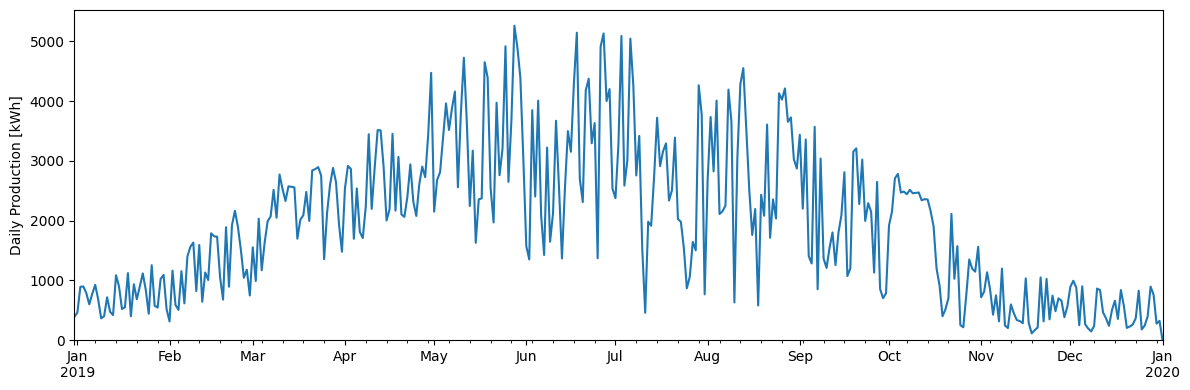

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
daily_energy = (mc.results.dc['p_mp'].resample('h').mean().resample('d').sum
                ()) / 1000
daily_energy.plot(ax=ax)
plt.ylim(bottom=0)
plt.ylabel('Daily Production [kWh]')
plt.tight_layout()

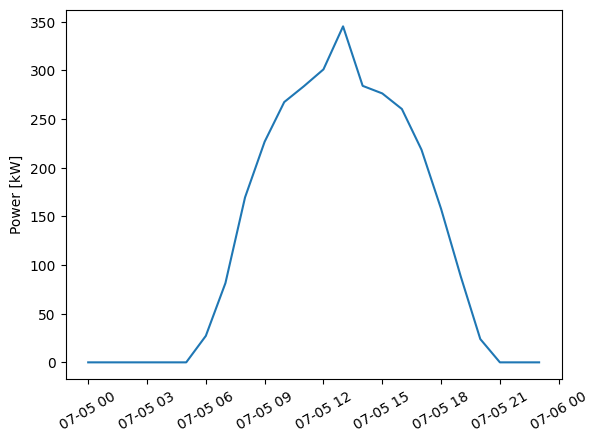

In [15]:
import matplotlib.pyplot as plt
DEMO_DAY = '2019-07-05'

plt.figure()
plt.plot(mc.results.dc['p_mp'][DEMO_DAY] *1e-3)
plt.xticks(rotation=30)
plt.ylabel('Power [kW]')
plt.show()

In [17]:
df

,dni,dhi,ghi,temp_air,wind_speed
2018-12-31 00:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 01:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 02:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 03:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 04:00:00+07:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2019-12-31 20:00:00+07:00,0.0,0.0,0.0,-19.30,2.60
2019-12-31 21:00:00+07:00,0.0,0.0,0.0,-20.01,2.73
2019-12-31 22:00:00+07:00,0.0,0.0,0.0,-20.50,2.85
2019-12-31 23:00:00+07:00,0.0,0.0,0.0,-20.74,2.89


In [18]:
mc.results.dc

,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx
2018-12-31 00:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-31 01:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-31 02:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-31 03:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-31 04:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
2019-12-31 20:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-12-31 21:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-12-31 22:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-12-31 23:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
from pathlib import Path
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'data.xlsx'
data = pd.read_excel(data_path, index_col=0)
data

,"Сасыр, kW","Solal, kW"
datetime,,
2019-01-01 00:00:00,201.000791,0.0
2019-01-01 01:00:00,179.721422,0.0
2019-01-01 02:00:00,171.304978,0.0
2019-01-01 03:00:00,173.068636,0.0
2019-01-01 04:00:00,159.528222,0.0
...,...,...
2019-12-31 19:00:00,277.786301,0.0
2019-12-31 20:00:00,238.908277,0.0
2019-12-31 21:00:00,240.645576,0.0


In [20]:
df

,dni,dhi,ghi,temp_air,wind_speed
2018-12-31 00:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 01:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 02:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 03:00:00+07:00,NaN,NaN,NaN,NaN,NaN
2018-12-31 04:00:00+07:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2019-12-31 20:00:00+07:00,0.0,0.0,0.0,-19.30,2.60
2019-12-31 21:00:00+07:00,0.0,0.0,0.0,-20.01,2.73
2019-12-31 22:00:00+07:00,0.0,0.0,0.0,-20.50,2.85
2019-12-31 23:00:00+07:00,0.0,0.0,0.0,-20.74,2.89


In [19]:
print(mc.results.dc.index.tz)
print(df.index.tz)
print(data.index.tz)

Asia/Krasnoyarsk
UTC
None


In [21]:
target_index = mc.results.dc.index


data.index = (
    pd.to_datetime(data.index)
      .tz_localize('Asia/Krasnoyarsk')  # UTC+7
)

# Перестраиваем по индексу mc.results.dc
data = data.reindex(target_index)

# Объединяем
result = pd.concat(
    [mc.results.dc, data],
    axis=1
)

In [22]:
result

,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx,"Сасыр, kW","Solal, kW"
2018-12-31 00:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-12-31 01:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-12-31 02:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-12-31 03:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-12-31 04:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-12-31 20:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238.908277,0.0
2019-12-31 21:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,240.645576,0.0
2019-12-31 22:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.358556,0.0
2019-12-31 23:00:00+07:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,183.208797,0.0


In [23]:
# result.drop(['dni', 'dhi', 'ghi', 'temp_air', 'wind_speed'], axis=1, inplace=True)
result.dropna(inplace=True)

In [24]:
result.drop(['Solal, kW'], axis=1, inplace=True)
result.rename(columns={'Сасыр, kW': 'Load, kW'}, inplace=True)
result['Solar, kW'] = result['p_mp'] * 1e-3

In [25]:
result.index.name = 'datetime'

In [26]:
from pathlib import Path
ROOT = Path().resolve().parents[1]
data_path = ROOT / 'src' / 'data' / 'dataset.xlsx'
result.index = result.index.tz_localize(None)
result.to_excel(data_path, index=True)

In [27]:
result

,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx,"Load, kW","Solar, kW"
datetime,,,,,,,,,
2019-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201.000791,0.0
2019-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,179.721422,0.0
2019-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,171.304978,0.0
2019-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,173.068636,0.0
2019-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,159.528222,0.0
...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,277.786301,0.0
2019-12-31 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238.908277,0.0
2019-12-31 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,240.645576,0.0
